
# MEEP: Straight Waveguide

This example demonstrates the propagation of electromagnetic energy in a dielectric waveguide.

Let's assume we have a **dielectric waveguide** with a length of 150 mm and a width of 12 mm, made of a material with a relative permittivity of **ε_r = 12**.

The waveguide is located within a larger simulation space with dimensions of 150 x 80 mm. The edges of this space are surrounded by a matched absorbing layer (**PML**) with a thickness of 5 mm.

At one end of the waveguide, a point-like, **continuous source** of electromagnetic waves with a frequency of **5 GHz** is placed to excite the structure.




## Configuration

We will take **1 mm** as the basic unit of length (`l₀`). The normalizing time constant (`t*`) will then be:

$$
t^{*} = \frac{l_0}{c} = \frac{1 \cdot 10^{-3} \text{ m}}{3 \cdot 10^8 \text{ m/s}} = 3.33 \cdot 10^{-12} \text{ s}
$$

The normalized dimensions of the waveguide will be **150 x 12** nodes, and the simulation environment will have dimensions of **150 x 80** nodes.

---

The period (`T`) of the **5 GHz** source in real-world units is:

$$
T = \frac{1}{f} = \frac{1}{ 5 \cdot 10^9 \text{ Hz}} = 2 \cdot 10^{-10} \text{ s}
$$

The normalized period (`T*`) in simulation steps is then calculated by dividing the real period by the MEEP time unit:

$$
T^{*} = \frac{T}{t^*} = \frac{2 \cdot 10^{-10} \text{ s}}{3.33 \cdot 10^{-12} \text{ s}} \approx 60
$$

And finally, the normalized frequency (`f*`) that will be used in the MEEP simulation is the reciprocal of the normalized period:

$$
f^* = \frac{1}{T^*} = \frac{1}{60} \approx 0.01667
$$


-----------
Initializing structure...
time for choose_chunkdivision = 5.4121e-05 s
Working in 2D dimensions.
Computational cell is 150 x 80 x 0 with resolution 1
     block, center = (0,0,0)
          size (1e+20,15,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4,4,4)
time for set_epsilon = 0.00658917 s
-----------


FloatProgress(value=0.0, description='0% done ', max=1000.0)

run 0 finished at t = 1000.0 (2000 timesteps)


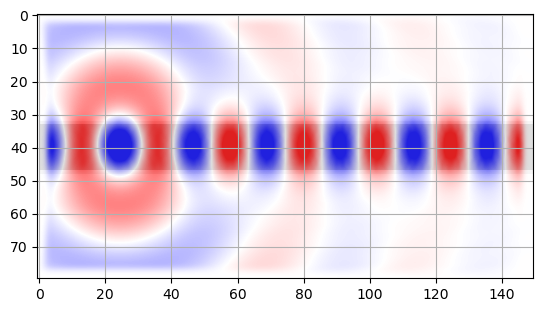

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import meep as mp

dx = 150
dy = 80
cell = mp.Vector3(dx, dy, 0)

geometry = [mp.Block(mp.Vector3(mp.inf, 15.0, 0),
                center=mp.Vector3(),
                material=mp.Medium(epsilon=4))]

sources = [mp.Source(mp.ContinuousSource(frequency=0.025), #0.0166),
            component=mp.Ez,
            center=mp.Vector3(-50, 0, 0))]

pml_layers = [mp.PML(5.0)]

resolution = 1

sim = mp.Simulation(cell_size=cell,
            boundary_layers=pml_layers,
            geometry=geometry,
            sources=sources,
            resolution=1)

sim.run(until=1000)

eps = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Ez).transpose()

fig = plt.figure(dpi=100)
ax = fig.add_subplot(111)
ax.imshow(eps.transpose(), cmap='binary', interpolation=None, extent=(0, dx, 0, dy), alpha=0.5)
ax.imshow(data, interpolation='spline36', cmap='bwr', alpha=0.75, norm=plt.Normalize(-0.02, 0.02))
ax.grid()
ax.set_aspect('equal')
plt.show()

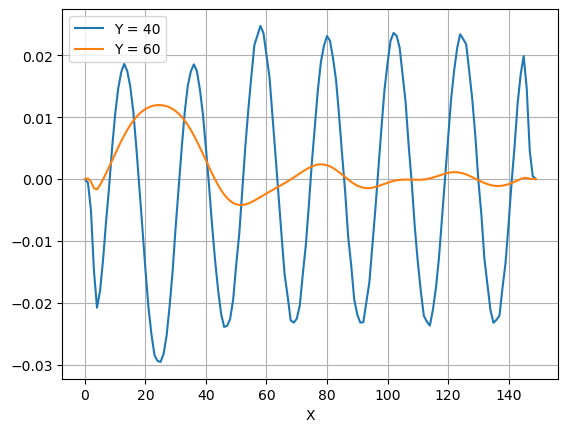

In [2]:
fig = plt.figure(dpi=100)
ax = fig.add_subplot(111)

plt.plot(data[40,:], label='Y = 40')
plt.plot(data[60,:], label='Y = 60')
plt.xlabel('X')
plt.grid()
plt.legend()
plt.show()